## **Imports**

In [14]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV


## **Data Exploration**

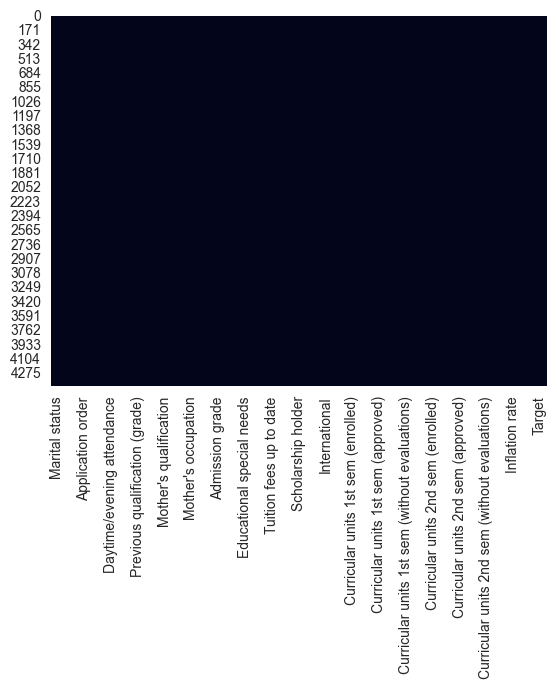

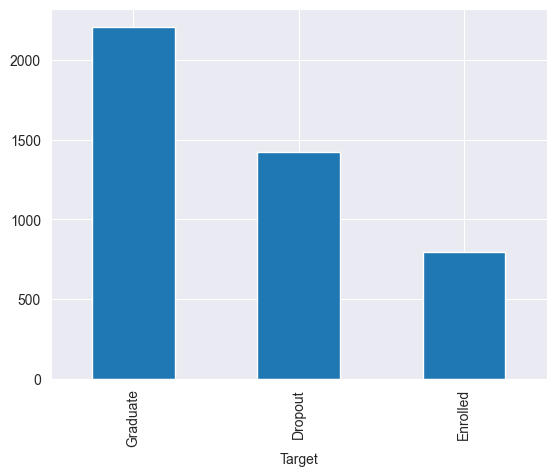

Marital status 6
Application mode 18
Application order 8
Course 17
Daytime/evening attendance 2
Previous qualification 17
Previous qualification (grade) 101
Nacionality 21
Mother's qualification 29
Father's qualification 34
Mother's occupation 32
Father's occupation 46
Admission grade 620
Displaced 2
Educational special needs 2
Debtor 2
Tuition fees up to date 2
Gender 2
Scholarship holder 2
Age at enrollment 46
International 2
Curricular units 1st sem (credited) 21
Curricular units 1st sem (enrolled) 23
Curricular units 1st sem (evaluations) 35
Curricular units 1st sem (approved) 23
Curricular units 1st sem (grade) 797
Curricular units 1st sem (without evaluations) 11
Curricular units 2nd sem (credited) 19
Curricular units 2nd sem (enrolled) 22
Curricular units 2nd sem (evaluations) 30
Curricular units 2nd sem (approved) 20
Curricular units 2nd sem (grade) 782
Curricular units 2nd sem (without evaluations) 10
Unemployment rate 10
Inflation rate 9
GDP 10
Target 3
     Target  Target_en

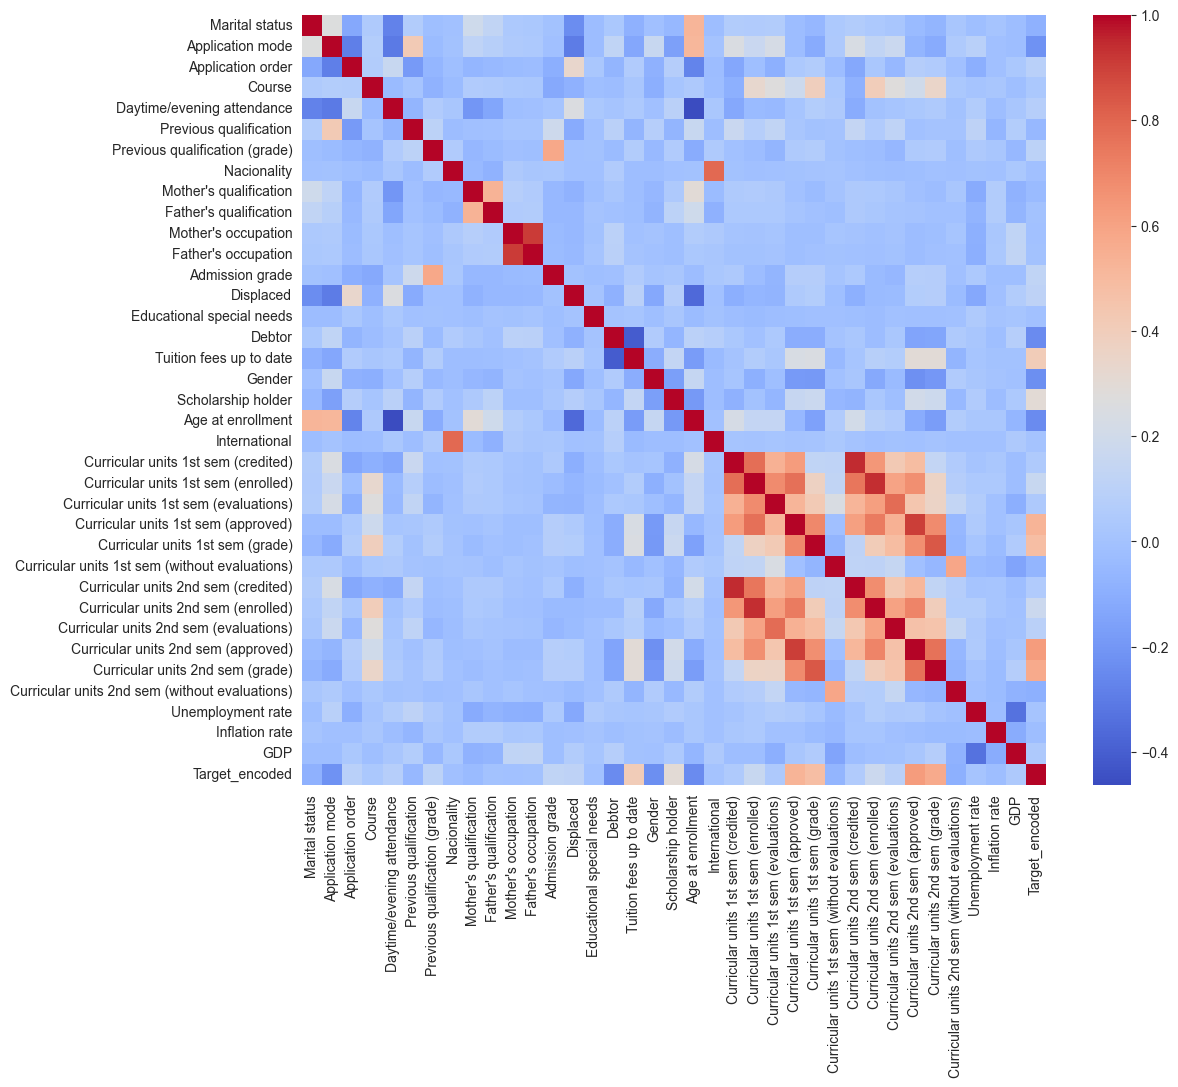

,feature,cramers_v
31,Curricular units 2nd sem (grade),0.573300
30,Curricular units 2nd sem (approved),0.545265
25,Curricular units 1st sem (grade),0.532533
24,Curricular units 1st sem (approved),0.481556
16,Tuition fees up to date,0.431458
12,Admission grade,0.402931
29,Curricular units 2nd sem (evaluations),0.313305
18,Scholarship holder,0.304407
23,Curricular units 1st sem (evaluations),0.302984
3,Course,0.251192


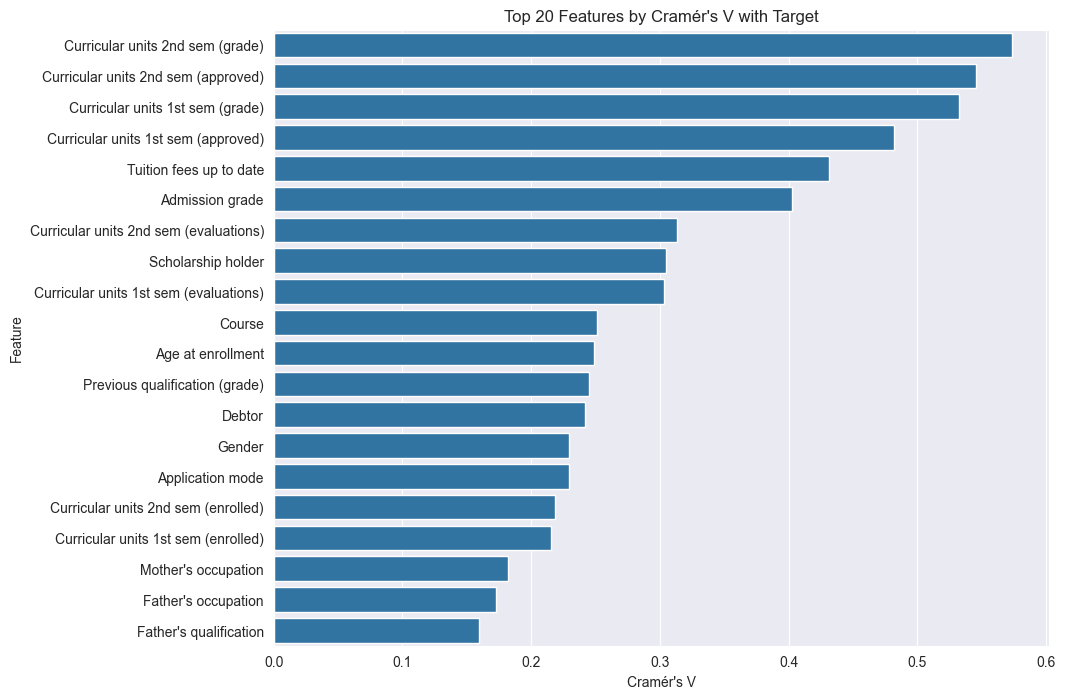

In [7]:
df = pd.read_csv("Data/Dropout_Academic Success - Sheet1.csv")

# see the structure of the dataset
pd.set_option('display.max_columns', None)
df.head()

# check for missing values
df.isnull().sum().sort_values()
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# check for class imbalance
df["Target"].value_counts()
df["Target"].value_counts().plot(kind="bar")
plt.show()

# check for unique values
for col in df.columns:
    print(col, df[col].nunique())

# Encode target values
encoder = LabelEncoder()
df["Target_encoded"] = encoder.fit_transform(df["Target"])
print(df[["Target", "Target_encoded"]].head())

# correlation matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

# correlation for categorical variables
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return (phi2 / min(k - 1, r - 1)) ** 0.5

cramer_results = []

for col in df.columns:
    if col not in ["Target", "Target_encoded"]:
        score = cramers_v(df[col], df["Target"])
        cramer_results.append({
            "feature": col,
            "cramers_v": score
        })

cramer_df = pd.DataFrame(cramer_results).sort_values("cramers_v", ascending=False)
display(cramer_df)
plt.figure(figsize=(10, 8))
sns.barplot(data=cramer_df.head(20), x="cramers_v", y="feature")
plt.title("Top 20 Features by Cramér's V with Target")
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.show()



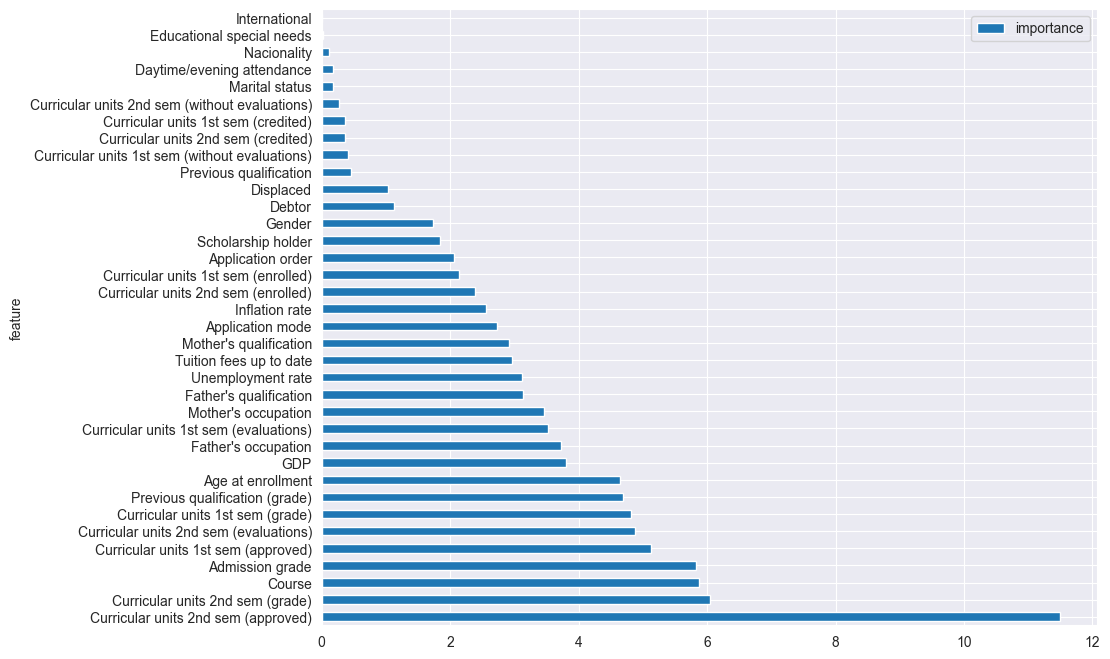

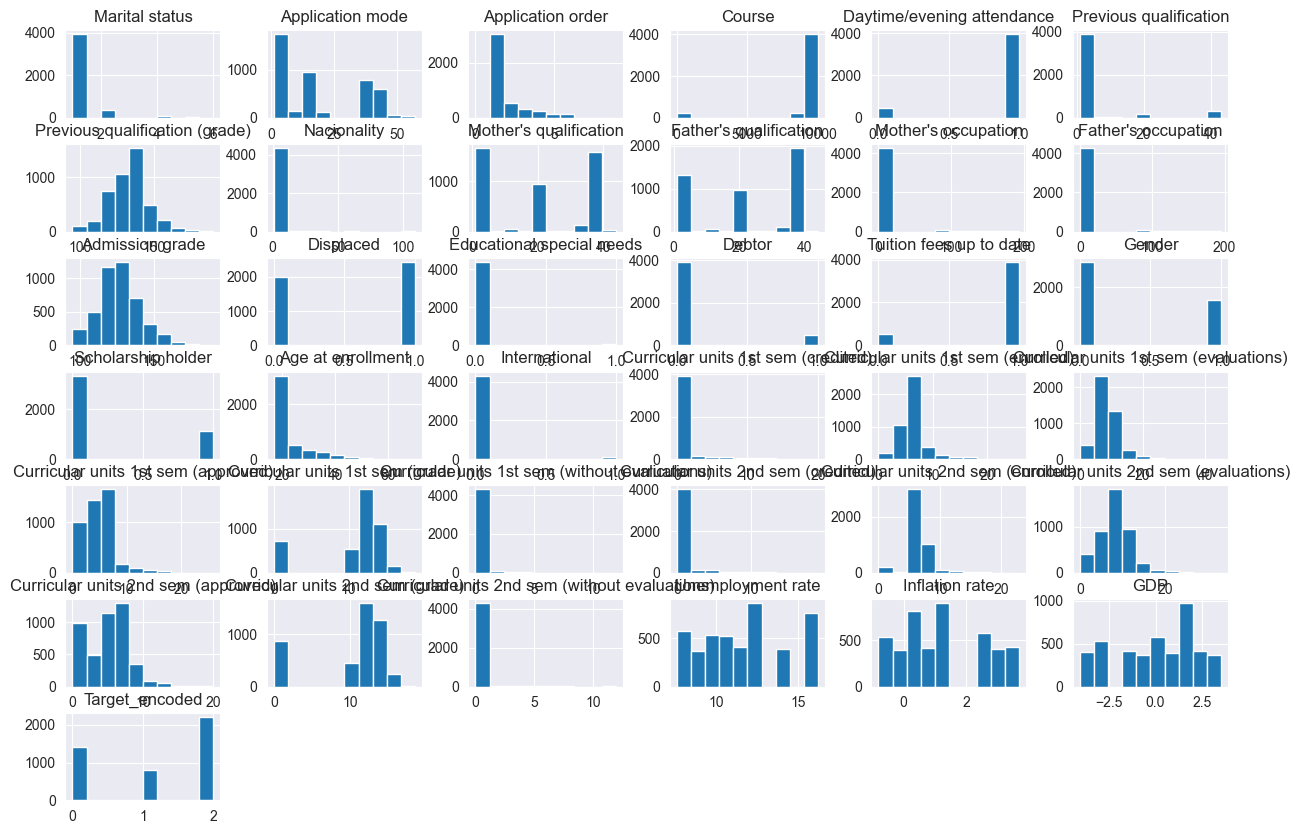


===== Marital status =====


Target,Dropout,Enrolled,Graduate
Marital status,,,
1,0.302118,0.183720,0.514162
2,0.472296,0.137203,0.390501
3,0.250000,0.500000,0.250000
4,0.461538,0.175824,0.362637
5,0.440000,0.120000,0.440000
6,0.666667,0.166667,0.166667



===== Application mode =====


Target,Dropout,Enrolled,Graduate
Application mode,,,
1,0.201991,0.175644,0.622365
2,0.666667,0.000000,0.333333
5,0.125000,0.500000,0.375000
7,0.611511,0.050360,0.338129
10,0.300000,0.000000,0.700000
15,0.166667,0.333333,0.500000
16,0.131579,0.210526,0.657895
17,0.293578,0.182339,0.524083
18,0.362903,0.129032,0.508065



===== Application order =====


...

Target,Dropout,Enrolled,Graduate
Unemployment rate,,,
7.6,0.353765,0.208406,0.437828
8.9,0.277174,0.209239,0.513587
9.4,0.326454,0.204503,0.469043
10.8,0.346667,0.171429,0.481905
11.1,0.282609,0.161836,0.555556
12.4,0.240449,0.202247,0.557303
12.7,0.336516,0.150358,0.513126
13.9,0.302564,0.164103,0.533333
15.5,0.350126,0.173804,0.476071



===== Inflation rate =====


Target,Dropout,Enrolled,Graduate
Inflation rate,,,
-0.8,0.326454,0.204503,0.469043
-0.3,0.302564,0.164103,0.533333
0.3,0.383978,0.127072,0.488950
0.5,0.240449,0.202247,0.557303
0.6,0.282609,0.161836,0.555556
1.4,0.318029,0.187010,0.494961
2.6,0.353765,0.208406,0.437828
2.8,0.350126,0.173804,0.476071
3.7,0.336516,0.150358,0.513126



===== GDP =====


Target,Dropout,Enrolled,Graduate
GDP,,,
-4.06,0.350126,0.173804,0.476071
-3.12,0.326454,0.204503,0.469043
-1.70,0.336516,0.150358,0.513126
-0.92,0.383978,0.127072,0.488950
0.32,0.353765,0.208406,0.437828
0.79,0.302564,0.164103,0.533333
1.74,0.346667,0.171429,0.481905
1.79,0.240449,0.202247,0.557303
2.02,0.282609,0.161836,0.555556


In [8]:
# Feature importance
X = df.drop(columns=["Target", "Target_encoded"])
y = df["Target_encoded"]
model = CatBoostClassifier(verbose=0)
model.fit(X, y)

importance = model.get_feature_importance()

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values("importance", ascending=False)

feat_imp.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10,8)
)
plt.show()

# distribution analysis
df.hist(figsize=(15,10))
plt.show()

# target relationship analysis
for col in df.columns:

    if col not in ["Target", "Target_encoded"]:

        print(f"\n===== {col} =====")

        cross = pd.crosstab(
            df[col],
            df["Target"],
            normalize="index"
        )

        display(cross)

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

## Exploration Findings

The exploratory data analysis showed that the dataset is clean and well-structured, with no major missing value issues present. A missing value heatmap and null value counts confirmed that all features contain complete or near-complete information, meaning no imputation techniques were required during preprocessing.

The target variable contains three classes: *Dropout*, *Graduate*, and *Enrolled*. The class distribution revealed a moderate imbalance, with the *Graduate* category containing the largest number of samples, while *Enrolled* appeared less frequently. Because of this imbalance, class weighting methods will likely be beneficial during model training.

The dataset primarily consists of encoded categorical variables such as marital status, course, nationality, application mode, parental qualifications, and occupation categories. Although these variables are stored numerically, the encoded values represent categories rather than continuous numerical relationships. This makes tree-based algorithms particularly suitable for the dataset, as they can effectively model categorical interactions without assuming linear relationships between encoded values.

Several features showed strong relationships with the target variable during the crosstab and Cramér’s V analysis. Variables such as course, application mode, previous qualification, tuition fee status, and curricular unit performance displayed noticeably different target distributions across categories. These findings suggest that the dataset contains meaningful predictive patterns related to academic success and dropout risk.

The analysis also identified multiple features with high cardinality and rare categories. Some encoded values appeared only a very small number of times, occasionally producing extreme target distributions such as categories with 100% dropout rates. These patterns are likely caused by insufficient sample sizes rather than genuine predictive certainty. Grouping rare categories into a shared “other” category will reduce noise and improve model generalization.

Correlation analysis showed that several academic performance variables are strongly related to one another. Features such as curricular units approved, evaluations, and grades demonstrated high correlation, which is expected because they measure related aspects of academic progress. While this multicollinearity is less problematic for tree-based methods such as CatBoost, it could negatively affect linear models.

Feature importance exploration further suggested that semester performance variables are among the strongest predictors in the dataset. Variables related to grades, approved curricular units, and tuition payment status appear highly informative for predicting student outcomes. However, these features may partially reflect future academic progression and therefore introduce mild target leakage. To evaluate this effect, an additional model without these features may be useful for comparison.

Overall, the data contains meaningful predictive structure, minimal missing data, and several strongly informative features. Based on these findings, a gradient boosting model such as CatBoost is an appropriate choice because it performs well on structured tabular datasets with many categorical variables and mixed feature types.

## **Pre-Processing**

In [5]:
# Remove duplicates
df = df.drop_duplicates()

# Group rare categories
min_count = 20
for col in X.columns:
    counts = df[col].value_counts()
    rare = counts[counts < min_count].index
    n_rare = len(rare)
    if n_rare > 0:
        print(f"\n{col}")
        print(f"Rare categories grouped: {n_rare}")
        print("Rare values:")
        print(list(rare)[:10])
        df[col] = df[col].replace(rare, -1)
        print("\nNew value counts:")
        print(df[col].value_counts().head())

# Train/test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))


Marital status
Rare categories grouped: 2
Rare values:
[6, 3]

New value counts:
Marital status
 1    3919
 2     379
 4      91
 5      25
-1      10
Name: count, dtype: int64

Application mode
Rare categories grouped: 6
Rare values:
[5, 10, 2, 57, 26, 27]

New value counts:
Application mode
1     1708
17     872
39     785
43     312
44     213
Name: count, dtype: int64

Application order
Rare categories grouped: 2
Rare values:
[9, 0]

New value counts:
Application order
1    3026
2     547
3     309
4     249
5     154
Name: count, dtype: int64

Course
Rare categories grouped: 1
Rare values:
[33]

New value counts:
Course
9500    766
9147    380
9238    355
9085    337
9773    331
Name: count, dtype: int64

Previous qualification
Rare categories grouped: 9
Rare values:
[6, 9, 4, 38, 43, 10, 15, 5, 14]

New value counts:
Previous qualification
 1     3717
 39     219
 19     162
 3      126
-1       56
Name: count, dtype: int64

Previous qualification (grade)
Rare categories grouped

## **Training Model**

In [15]:
base_model = CatBoostClassifier(
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=0
)

param_grid = {
    "iterations": [300, 500, 800, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "depth": [4, 5, 6, 7, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "border_count": [32, 64, 128],
    "bagging_temperature": [0, 0.5, 1, 2, 5]
}

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=25,
    scoring="f1_macro",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV macro F1:")
print(search.best_score_)


best_model = search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters:
{'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 8, 'border_count': 64, 'bagging_temperature': 0}

Best CV macro F1:
0.7153163076047234
Test accuracy: 0.7570621468926554

Classification report:
              precision    recall  f1-score   support

     Dropout       0.85      0.71      0.77       284
    Enrolled       0.46      0.62      0.53       159
    Graduate       0.85      0.84      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.72      0.72       885
weighted avg       0.78      0.76      0.76       885



## **Evaluate Model**

Accuracy: 0.7570621468926554

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.85      0.71      0.77       284
    Enrolled       0.46      0.62      0.53       159
    Graduate       0.85      0.84      0.84       442

    accuracy                           0.76       885
   macro avg       0.72      0.72      0.72       885
weighted avg       0.78      0.76      0.76       885



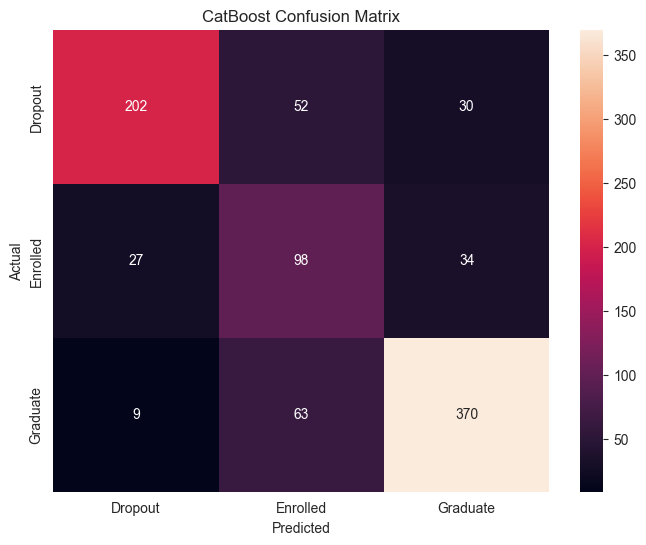

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CatBoost Confusion Matrix")
plt.show()